# Comparación de Posibles Modelos - AndesLink Churn

Este notebook tiene como objetivo experimentar con diferentes algoritmos de clasificación para predecir el churn de clientes. 
Se compararán:
1. **Logistic Regression** (Línea base)
2. **Random Forest** (Sugerido en `params.yml`)
3. **XGBoost** (Potencial modelo de alta performance)

**Foco principal:** Maximizar el **Recall** para la clase 1 (Churn).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score

### 1. Carga de Datos y Configuración

### 1. Ingesta de Datos y División Estratégica (Split)

En esta primera etapa, preparamos el terreno para el modelado siguiendo buenas prácticas de MLOps:
* **Parametrización:** Extraemos variables clave (como el tamaño del set de prueba y la semilla aleatoria) directamente de nuestro archivo de configuración `params.yml`. Esto facilita la reproducibilidad del experimento.
* **Prevención de Ruido:** Basados en los hallazgos del EDA (Hito 1), eliminamos la columna `total_charges` para evitar problemas de multicolinealidad estructural.
* **Muestreo Estratificado:** Al dividir los datos en Entrenamiento (80%) y Prueba (20%), aplicamos `stratify=y`. Dado que nuestro dataset está desbalanceado (34% Churn), esto garantiza que ambos conjuntos mantengan exactamente la misma proporción de fuga, evitando sesgos en la evaluación.

In [9]:
# Cargar parámetros desde params.yml
with open('../params.yml', 'r') as f:
    params = yaml.safe_load(f)

target_col = params['prepare']['target_column'].lower() # El CSV tiene 'churn' en minúscula según el EDA

# Cargar dataset
df = pd.read_csv('../data/raw/churn_sintetico.csv')

# Eliminar total_charges por multicolinealidad (según hallazgos del Hito 1)
df = df.drop(columns=['total_charges'])

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=params['prepare']['test_size'], 
    random_state=params['prepare']['random_state'],
    stratify=y
)

print(f"Dimensiones entrenamiento: {X_train.shape}")
print(f"Dimensiones prueba: {X_test.shape}")

Dimensiones entrenamiento: (4000, 14)
Dimensiones prueba: (1000, 14)


### 2. Preprocesamiento Seguro (Evitando Data Leakage)

Los algoritmos de Machine Learning requieren datos numéricos estandarizados. Para ello, construimos un motor de transformación (`ColumnTransformer`):
* **Variables Numéricas:** Pasan por un `StandardScaler` para que todas tengan el mismo peso y magnitud.
* **Variables Categóricas:** Pasan por un `OneHotEncoder`, transformando texto (ej. tipo de contrato) en formato binario.

**Decisión Arquitectónica:** Empaquetaremos este preprocesador dentro de un `Pipeline` en el siguiente paso. Esto asegura que las transformaciones se "aprendan" únicamente con los datos de entrenamiento, previniendo la fuga de información (Data Leakage) hacia el set de prueba.

In [10]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### 3 y 4 Entrenamiento de Modelos y Evaluación Orientada a Negocio

Someteremos a prueba tres algoritmos distintos:
1. **Regresión Logística:** Nuestro modelo base (*baseline*), simple e interpretable.
2. **Random Forest:** Un modelo de ensamble robusto basado en múltiples árboles de decisión.
3. **XGBoost:** Un algoritmo avanzado de Gradient Boosting, conocido por su alta performance.

**Métrica Estrella: El Recall**
Debido a la naturaleza del problema de AndesLink, nuestro objetivo financiero es **minimizar la fuga no detectada**. Por lo tanto, no nos guiaremos por el *Accuracy* general, sino que priorizaremos el **Recall de la clase 1 (Churn)**. Preferimos asumir el costo operativo de algunas falsas alarmas (baja Precisión) antes que perder a un cliente real por no haberlo detectado a tiempo (falso negativo). Se aplicaron pesos balanceados (`class_weight`, `scale_pos_weight`) para forzar a los algoritmos a prestar atención a la clase minoritaria.

#### 3. Definición y Evaluación de Modelos

In [11]:
def evaluate_model(model, name, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    return {
        'Model': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    }


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.82      0.64      0.72       660
           1       0.51      0.73      0.60       340

    accuracy                           0.67      1000
   macro avg       0.67      0.69      0.66      1000
weighted avg       0.72      0.67      0.68      1000



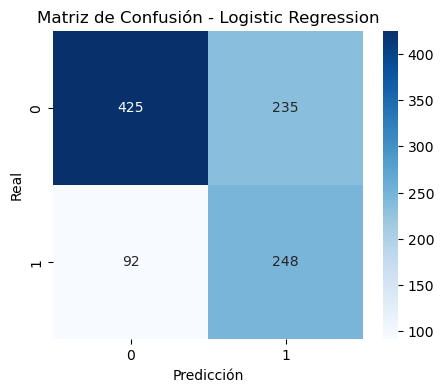


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.78      0.70      0.74       660
           1       0.51      0.63      0.56       340

    accuracy                           0.67      1000
   macro avg       0.65      0.66      0.65      1000
weighted avg       0.69      0.67      0.68      1000



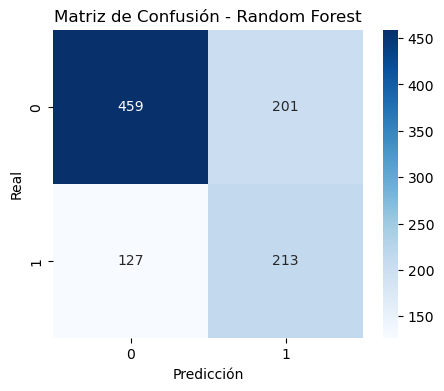

c:\Users\wvdov\anaconda3\envs\andeslink-churn\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:54:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
              precision    recall  f1-score   support

           0       0.75      0.74      0.74       660
           1       0.51      0.51      0.51       340

    accuracy                           0.66      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.67      0.66      0.66      1000



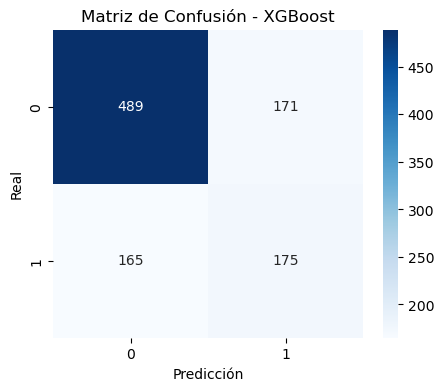

In [12]:
results = []

# 1. Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
results.append(evaluate_model(lr_model, "Logistic Regression", X_train, X_test, y_train, y_test))

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=params['train']['n_estimators'],
    max_depth=params['train']['max_depth'],
    class_weight=params['train']['class_weight'],
    random_state=params['train']['random_state']
)
results.append(evaluate_model(rf_model, "Random Forest", X_train, X_test, y_train, y_test))

# 3. XGBoost
# Calculamos scale_pos_weight para balanceo (aprox sum(neg)/sum(pos))
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
results.append(evaluate_model(xgb_model, "XGBoost", X_train, X_test, y_train, y_test))

#### 4. Comparación de Métricas

                 Model    Recall  Precision  F1-Score   ROC-AUC
0  Logistic Regression  0.729412   0.513458  0.602673  0.757496
1        Random Forest  0.626471   0.514493  0.564987  0.735896
2              XGBoost  0.514706   0.505780  0.510204  0.699153


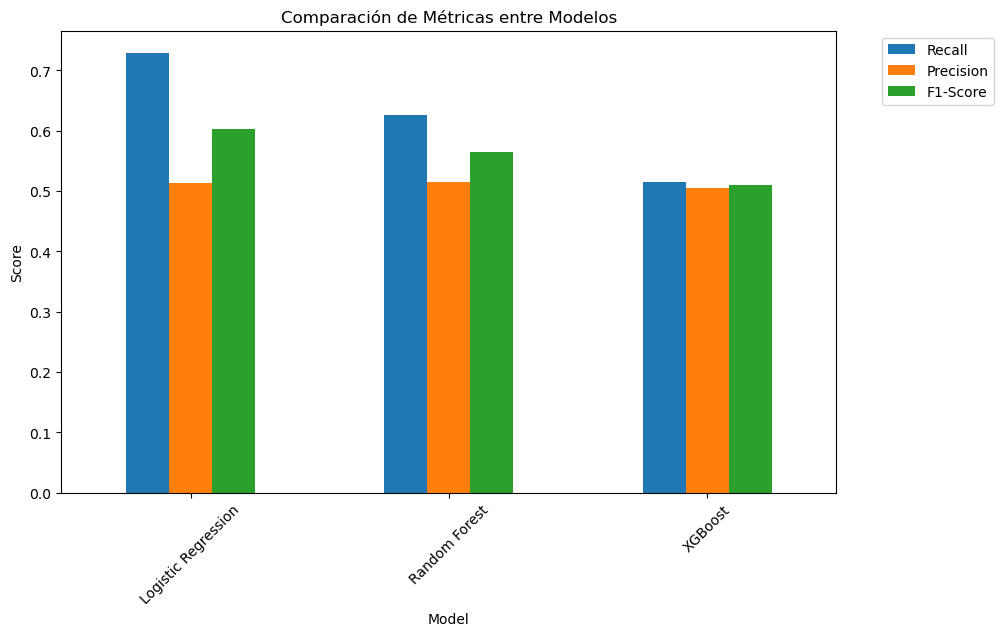

In [13]:
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Recall', ascending=False))

results_df.set_index('Model')[['Recall', 'Precision', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Métricas entre Modelos')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 5. Optimización de Hiperparámetros (Tuning Random Forest)

Si bien la Regresión Logística mostró un buen rendimiento inicial, el Random Forest tiene mayor potencial de mejora. 
Realizamos una búsqueda aleatoria para encontrar los mejores parámetros de Random Forest priorizando el **Recall**.

Utilizaremos `RandomizedSearchCV` para explorar de manera automatizada y eficiente 10 configuraciones distintas del "bosque" (ajustando la profundidad de los árboles, la cantidad de estimadores, etc.). 
**El factor clave:** Hemos configurado la búsqueda para que el algoritmo seleccione los mejores hiperparámetros optimizando **estrictamente la métrica `recall`**. El objetivo es encontrar la sintonía fina que nos permita capturar la mayor cantidad de clientes en riesgo de abandono para nuestro modelo definitivo.

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=5, 
    scoring='recall', 
    n_jobs=-1, 
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {random_search.best_params_}")
print(f"Mejor Recall (CV): {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n--- Reporte con Mejores Parámetros ---")
print(classification_report(y_test, y_pred_best))

Mejores parámetros encontrados: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 5, 'classifier__bootstrap': False}
Mejor Recall (CV): 0.7797

--- Reporte con Mejores Parámetros ---
              precision    recall  f1-score   support

           0       0.82      0.57      0.67       660
           1       0.48      0.75      0.58       340

    accuracy                           0.64      1000
   macro avg       0.65      0.66      0.63      1000
weighted avg       0.70      0.64      0.64      1000



---

### Análisis de Resultados y Selección del Modelo Definitivo

Tras evaluar los tres algoritmos base y realizar la optimización de hiperparámetros, extraemos las siguientes conclusiones estratégicas para **AndesLink**:

**1. Comparación Inicial (Baseline):**
En la primera prueba, la *Regresión Logística* con balanceo de clases demostró ser un modelo base robusto, logrando un Recall del ~73%. Por su parte, los modelos complejos (*Random Forest* y *XGBoost*) presentaron un rendimiento inicial inferior en esta métrica (~63% y ~51% respectivamente), indicando que sus configuraciones por defecto no se adaptaban bien a la prioridad de capturar la clase minoritaria (fugas).

**2. El Impacto de la Optimización (Tuning):**
Al intervenir el *Random Forest* mediante `RandomizedSearchCV` y forzarlo a optimizar estrictamente el **Recall**, el algoritmo identificó que una estructura más controlada y menos profunda (`max_depth=5`, `n_estimators=50`) generaliza mejor. Esto disparó nuestro Recall en el set de prueba a un sólido **75%**.

**3. El *Trade-Off* de Negocio (Precisión vs. Recall):**
El modelo definitivo (Random Forest Optimizado) presenta un Recall del **75%** y una Precisión del **48%**. En impacto comercial, esto se traduce en lo siguiente:
* **El Logro (Recall 75%):** El modelo tiene la sensibilidad necesaria para detectar a 3 de cada 4 clientes que *realmente* van a cancelar su servicio. 
* **El Costo Operativo (Precisión 48%):** Habrá "falsas alarmas". Aproximadamente la mitad de los clientes perfilados como riesgo por el modelo, en realidad pensaban quedarse.

**Recomendación Ejecutiva:**
Desde la perspectiva de retención, **este es el comportamiento deseado**. El costo de enviar una promoción preventiva, una llamada de cortesía o un correo de atención al cliente a un usuario leal (Falso Positivo) es prácticamente nulo. En cambio, el impacto financiero de perder a un cliente real por no haberlo detectado a tiempo (Falso Negativo) es altísimo. Este modelo cumple el objetivo primordial de AndesLink: construir una red de seguridad proactiva contra el Churn.

---
---

### 7. Trazabilidad y Empaquetamiento del Modelo (MLflow)

Para cumplir con los estándares de arquitectura MLOps definidos para el **Hito 1**, no basta con entrenar un buen modelo; debemos garantizar su **reproducibilidad** y preparar el terreno para su **despliegue**. 

En lugar de simplemente exportar un archivo suelto, utilizamos **MLflow** para crear un registro oficial e inmutable de nuestro experimento ganador:
* **Tracking de Parámetros y Métricas:** Guardamos la configuración exacta del Random Forest optimizado y sus resultados clave (Recall, Precision). Esto genera un historial de auditoría valioso para comparar futuras iteraciones del modelo.
* **Inferencia de Firma (Signature):** Le indicamos a MLflow la estructura exacta de los datos que espera recibir el modelo (tipos de datos y columnas). Este paso es un puente crítico hacia el **Hito 2**, ya que asegurará que nuestra futura API (FastAPI) se comunique correctamente con el modelo.
* **Serialización de Artefactos:** Guardamos el *pipeline* completo (que incluye tanto la transformación de datos como el algoritmo predictivo) como un artefacto seguro y listo para producción, respaldándolo también en un archivo `.pkl` tradicional.

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

print("\n--- REGISTRO DEL MODELO EN MLFLOW ---")

# 1. Configuramos el experimento (si no existe, lo crea)
mlflow.set_experiment("AndesLink_Churn_Prediction")

# 2. Iniciamos el tracking del modelo ganador (Random Forest Optimizado)
with mlflow.start_run(run_name="Optimized_Random_Forest"):
    
    # Registramos los hiperparámetros que encontramos con RandomizedSearchCV
    mlflow.log_params(random_search.best_params_)
    
    # Registramos las métricas de negocio
    mlflow.log_metric("recall_class_1", recall_score(y_test, y_pred_best))
    mlflow.log_metric("precision_class_1", precision_score(y_test, y_pred_best))
    mlflow.log_metric("f1_class_1", f1_score(y_test, y_pred_best))
    
    # Inferimos la "firma" del modelo (qué entra y qué sale, útil para la API)
    signature = infer_signature(X_test, y_pred_best)
    
    # Registramos el modelo completo (incluyendo el preprocesador)
    mlflow.sklearn.log_model(
        sk_model=best_rf, 
        artifact_path="churn_model",
        signature=signature,
        input_example=X_test.iloc[[0]] # Un ejemplo de los datos de entrada
    )
    
    # También podemos guardarlo localmente como un archivo .joblib tradicional (opcional pero recomendado)
    import joblib
    joblib.dump(best_rf, '../models/churn_model.pkl')
    
    print(f"✅ Experimento registrado exitosamente en MLflow.")
    print("✅ Modelo guardado localmente en 'models/churn_model.pkl'.")